# 01 · Preprocesamiento — Credit Risk Copilot

**Fase 1 · Datos y EDA.** Exploración visual y narrativa del dataset *Default of Credit
Card Clients* (UCI 350) y de las decisiones que produjeron el pipeline de
preprocesamiento del proyecto.

---

## El problema de negocio

Una entidad que otorga crédito rotativo necesita estimar **la probabilidad de que un
cliente incumpla el pago del próximo período**. De esa estimación cuelgan tres decisiones:
aprobar o rechazar, fijar tasa y cupo, y provisionar capital regulatorio.

Los dos errores no cuestan lo mismo. Un **falso negativo** —aprobar a quien incumple—
pierde el principal. Un **falso positivo** —rechazar a quien habría pagado— pierde un
ingreso. El primero suele ser varias veces más caro, y eso define la métrica del proyecto.

## La pregunta que responde este notebook

> **¿Qué contiene realmente este dataset, y por qué el pipeline de preprocesamiento es
> como es?**

No es la misma pregunta que "¿qué modelo entrenamos?". Acá no se entrena nada y no se mide
poder predictivo. Lo que se mide es el **dato**, y lo que se explica son las **decisiones**
que el dato forzó.

## Cómo leer este notebook

Tres cosas que conviene saber antes de la primera celda.

**1 · Toda la lógica se importa; acá no se reimplementa nada.** El notebook no define
funciones de transformación, no recalcula features a mano y no reconstruye ningún paso del
pipeline. Todo sale de `credit_copilot`. La razón está en la sección 7.4 de
`docs/METHODOLOGY.md`: un notebook con lógica propia se convierte en una segunda
implementación que diverge de la de producción sin avisar. Lo único que se escribe acá son
**agregaciones de pandas para dibujar** y el código de los gráficos.

**2 · Este notebook no es la medición de registro.** Las mediciones que sostienen las
decisiones se hicieron con scripts reproducibles —`scripts/analyze_undocumented_codes.py`—
y viven en `docs/analysis/undocumented-codes-evidence.md`. Acá se **narran y se dibujan**.
Un evaluador que lea solo este notebook debería entender el dataset y las decisiones; un
evaluador que quiera auditar las cifras va al script.

**3 · Toda cifra que aparece sale de ejecutar código.** Los gráficos se anotan con los
valores calculados en la misma celda. Cuando el texto cita un número entre comillas es
porque **cita un documento del proyecto** (un ADR), y lo dice explícitamente.

### Las decisiones que este notebook explica

| Decisión | Dónde vive |
| --- | --- |
| PR-AUC y no *accuracy* como métrica principal | ADR-0002 |
| Significado aceptado de los códigos `-2` y `0` de `PAY_STATUS` | ADR-0004 §1 |
| `PAY_STATUS` es categórica, **no** ordinal | ADR-0004 §2 |
| El mes 1 no comparte la escala de los meses 2 a 6 | ADR-0004 §3 |
| `EDUCATION` se colapsa; `MARRIAGE` **no** | ADR-0004 §4 y §5 |
| `ID` se elimina en la carga | ADR-0004 §6 |
| Diseño de las features de comportamiento y piso de denominador | ADR-0005 |

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from credit_copilot.data import schema
from credit_copilot.data.loader import load_dataset
from credit_copilot.data.preprocessor import (
    CATEGORICAL_COLUMNS,
    INDICATOR_COLUMNS,
    NUMERIC_COLUMNS,
    NUMERIC_SOURCE_COLUMNS,
    build_preprocessor,
    learned_parameters,
)
from credit_copilot.data.validator import validate_dataframe
from credit_copilot.features.builder import (
    BLOCK_MONTHS,
    FEATURE_NAMES,
    PAYMENT_RATIO_FEATURES,
    PAYMENT_RATIO_MONTHS,
    PaymentBehaviourFeatures,
)

plt.rcParams.update(
    {
        "figure.dpi": 92,
        "savefig.dpi": 92,
        "font.size": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.autolayout": True,
    }
)

# One palette for the whole notebook, so a colour always means the same thing.
NO_DEFAULT, DEFAULT = "#4C72B0", "#C44E52"
NEUTRAL, HIGHLIGHT = "#8C8C8C", "#DD8452"

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

---

# 2 · Carga y contrato de datos

El proyecto tiene **una sola puerta de entrada al dato**: `loader.load_dataset()`. Aplica
los nombres canónicos y elimina `ID`.

Que `ID` desaparezca en la carga no es comodidad. `docs/DATA_DICTIONARY.md` decía que `ID`
*"nunca debe usarse como feature"*, y eso es una garantía de **nivel 3** en el sentido de
la sección 6.5 de la metodología —"está escrito en un documento"— y el nivel 3 falla.
Eliminarla en la carga la sube a **nivel 1**: no puede usarse porque no existe en la tabla.

In [2]:
frame = load_dataset()
print(f"Filas: {frame.shape[0]:,}   Columnas: {frame.shape[1]}")
print(f"Target: {schema.TARGET_COLUMN}")
print(f"'ID' presente en la tabla de trabajo: {schema.ID_COLUMN in frame.columns}")
frame.head(3)

Filas: 30,000   Columnas: 24
Target: DEFAULT_PAYMENT_NEXT_MONTH
'ID' presente en la tabla de trabajo: False


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_STATUS_1,PAY_STATUS_2,PAY_STATUS_3,PAY_STATUS_4,PAY_STATUS_5,PAY_STATUS_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_PAYMENT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## El validador como evidencia

El contrato no se supone: se verifica. `validate_dataframe` compara la tabla contra
`schema` —columnas, tipos, rangos, categorías y duplicados— y **separa lo bloqueante de lo
informativo**. Un código no documentado que un ADR aceptó sobre evidencia medida es
informativo y **cita el ADR**; un código que nadie miró todavía sigue siendo bloqueante.

Esa separación es lo que mantiene al validador útil. Un validador en rojo permanente deja
de leerse.

In [3]:
result = validate_dataframe(frame)
print(result.report())

DATA CONTRACT VALIDATION
Rows: 30,000    Columns: 24

-- Null count per column ---------------------------------------------------
  LIMIT_BAL                             0
  SEX                                   0
  EDUCATION                             0
  MARRIAGE                              0
  AGE                                   0
  PAY_STATUS_1                          0
  PAY_STATUS_2                          0
  PAY_STATUS_3                          0
  PAY_STATUS_4                          0
  PAY_STATUS_5                          0
  PAY_STATUS_6                          0
  BILL_AMT1                             0
  BILL_AMT2                             0
  BILL_AMT3                             0
  BILL_AMT4                             0
  BILL_AMT5                             0
  BILL_AMT6                             0
  PAY_AMT1                              0
  PAY_AMT2                              0
  PAY_AMT3                              0
  PAY_AMT4                   

**Lectura.** El contrato se cumple: **cero hallazgos bloqueantes**. Los informativos son
exactamente los que el ADR-0004 aceptó — los códigos no documentados de `EDUCATION`,
`MARRIAGE` y los seis `PAY_STATUS_*` — y cada uno viene con la razón por la que se aceptó.

El último informativo merece atención: la detección de **duplicados exactos no se corre**,
porque `ID` ya no está en esta tabla y sin identificador no se puede distinguir un extracto
roto de dos clientes distintos con atributos idénticos. No es una falla: es la consecuencia
declarada de la decisión anterior, y el validador la reporta en vez de callarla.

---

# 3 · El target y por qué `accuracy` es inútil acá

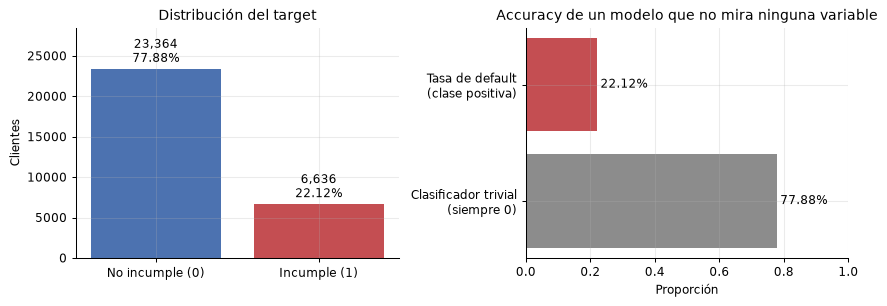

Positivos: 6,636 de 30,000  (22.12%)
Accuracy del clasificador trivial: 77.88%


In [4]:
target = frame[schema.TARGET_COLUMN]
counts = target.value_counts().sort_index()
shares = counts / len(frame)
majority_accuracy = shares.max()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))

bars = axes[0].bar(["No incumple (0)", "Incumple (1)"], counts, color=[NO_DEFAULT, DEFAULT])
for bar, count, share in zip(bars, counts, shares, strict=True):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        count + 400,
        f"{count:,}\n{share:.2%}",
        ha="center",
        va="bottom",
    )
axes[0].set_ylim(0, counts.max() * 1.22)
axes[0].set_ylabel("Clientes")
axes[0].set_title("Distribución del target")

axes[1].barh(
    ["Clasificador trivial\n(siempre 0)", "Tasa de default\n(clase positiva)"],
    [majority_accuracy, shares.loc[1]],
    color=[NEUTRAL, DEFAULT],
)
for y, value in enumerate([majority_accuracy, shares.loc[1]]):
    axes[1].text(value + 0.01, y, f"{value:.2%}", va="center")
axes[1].set_xlim(0, 1.0)
axes[1].set_xlabel("Proporción")
axes[1].set_title("Accuracy de un modelo que no mira ninguna variable")

plt.show()
print(f"Positivos: {counts.loc[1]:,} de {len(frame):,}  ({shares.loc[1]:.2%})")
print(f"Accuracy del clasificador trivial: {majority_accuracy:.2%}")

**Lectura — visualización 1.** El desbalance es moderado pero decisivo: alrededor de una
de cada cinco filas es un incumplimiento.

La barra gris de la derecha es el argumento entero del **ADR-0002**. Un modelo que ignore
todas las variables y prediga siempre *"no incumple"* obtiene esa *accuracy*, y **no
identifica ni un solo caso de los que importan**. Es una métrica que no puede fallar, y una
métrica que no puede fallar no prueba nada.

Por eso la métrica de decisión del proyecto es **PR-AUC**. El mecanismo, en una línea: el
eje X de la curva ROC es la tasa de falsos positivos, cuyo denominador son *todos los
negativos reales*; con la clase negativa dominando, ese denominador absorbe los falsos
positivos sin que la curva se mueva. La curva PR usa precisión, cuyo denominador son *solo
las predicciones positivas*, y sí refleja el costo de equivocarse sobre la clase escasa.

> **ADR-0002.** PR-AUC como métrica de decisión; ROC-AUC, KS, Gini, Brier y
> precision@top-10% como métricas de contexto obligatorias. Toda métrica se reporta junto a
> su baseline.

---

# 4 · Los códigos no documentados — el corazón del dataset

Acá está la historia central. La documentación oficial de UCI declara, para las seis
columnas de estado de pago:

> *"-1 = pay duly; 1 = payment delay for one month; …; 9 = payment delay for nine months
> and above."*

**No declara el `0` ni el `-2`.** Y sin embargo el `0` es el valor *modal* de la columna.
Este no es un problema de datos sucios: es que **la documentación de la fuente describe
correctamente una minoría de los datos**.

Las cuatro visualizaciones que siguen reproducen gráficamente la evidencia que llevó al
**ADR-0004**, medida en `scripts/analyze_undocumented_codes.py` y registrada en
`docs/analysis/undocumented-codes-evidence.md`.

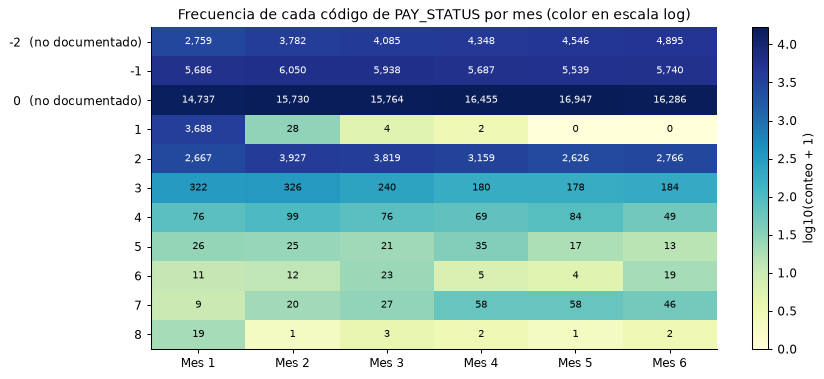

Filas con un codigo no documentado en PAY_STATUS (-2 o 0): 25,939 (86.46%)
Filas con un codigo no documentado en cualquier columna:   25,970 (86.57%)   <- cifra de cabecera del ADR-0004


In [5]:
documented = sorted(schema.CATEGORICAL_LEVELS["PAY_STATUS_1"])
code_matrix = (
    pd.DataFrame({column: frame[column].value_counts() for column in schema.PAY_STATUS_COLUMNS})
    .fillna(0)
    .astype(int)
    .sort_index()
)

repayment_hit = frame[list(schema.PAY_STATUS_COLUMNS)].isin([-2, 0]).any(axis=1)
demographic_hit = frame["EDUCATION"].isin([0, 5, 6]) | frame["MARRIAGE"].isin([0])
any_hit = repayment_hit | demographic_hit

fig, ax = plt.subplots(figsize=(9.5, 4.2))
image = ax.imshow(np.log10(code_matrix.to_numpy() + 1), aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(code_matrix.columns)))
ax.set_xticklabels([c.replace("PAY_STATUS_", "Mes ") for c in code_matrix.columns])
ax.set_yticks(range(len(code_matrix.index)))
ax.set_yticklabels(
    [f"{c}  (no documentado)" if c not in documented else str(c) for c in code_matrix.index]
)
for row in range(code_matrix.shape[0]):
    for col in range(code_matrix.shape[1]):
        value = code_matrix.iat[row, col]
        ax.text(
            col,
            row,
            f"{value:,}" if value else "0",
            ha="center",
            va="center",
            fontsize=7.5,
            color="white" if np.log10(value + 1) > 2.6 else "black",
        )
ax.set_title("Frecuencia de cada código de PAY_STATUS por mes (color en escala log)")
ax.grid(False)
fig.colorbar(image, ax=ax, label="log10(conteo + 1)")
plt.show()

print(
    f"Filas con un codigo no documentado en PAY_STATUS (-2 o 0): "
    f"{repayment_hit.sum():,} ({repayment_hit.mean():.2%})"
)
print(
    f"Filas con un codigo no documentado en cualquier columna:   "
    f"{any_hit.sum():,} ({any_hit.mean():.2%})   <- cifra de cabecera del ADR-0004"
)

**Lectura — visualización 2.** Dos hechos saltan de la tabla.

El primero: **los códigos que la fuente no documenta dominan la columna.** El `0` es el
valor más frecuente en los seis meses y el `-2` es el segundo o el tercero. Las dos
proporciones impresas debajo del gráfico son la mayoría del dataset — la segunda, que suma
también los códigos sin documentar de `EDUCATION` y `MARRIAGE`, es la **cifra de cabecera
del ADR-0004**. Un contrato de datos que solo admitiera lo declarado rechazaría el dataset
entero, y el validador se volvería un rojo permanente que nadie vuelve a leer.

El segundo, y es el que arma toda la fase 1: **la fila del código `1` no se comporta como
las demás.** En el mes 1 aparece miles de veces; en los meses 2 a 6 aparece un puñado de
veces o ninguna. Ninguna otra fila de esta tabla hace eso. La siguiente visualización lo
aísla.

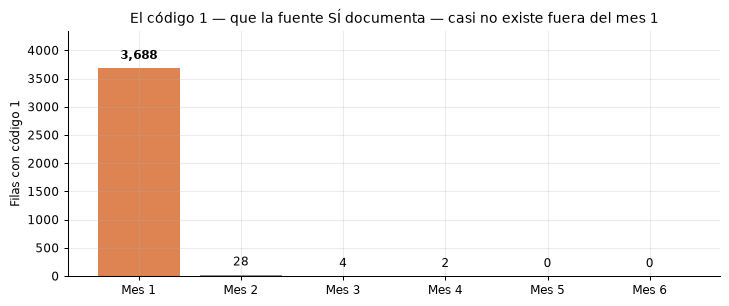

Codigo 1 por mes: {'PAY_STATUS_1': 3688, 'PAY_STATUS_2': 28, 'PAY_STATUS_3': 4, 'PAY_STATUS_4': 2, 'PAY_STATUS_5': 0, 'PAY_STATUS_6': 0}


In [6]:
code_one = code_matrix.loc[1]

fig, ax = plt.subplots(figsize=(8.0, 3.4))
colors = [HIGHLIGHT] + [NEUTRAL] * (len(code_one) - 1)
bars = ax.bar([c.replace("PAY_STATUS_", "Mes ") for c in code_one.index], code_one, color=colors)
for bar, value in zip(bars, code_one, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        max(value, 0) + max(code_one) * 0.03,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold" if value > 100 else "normal",
    )
ax.set_ylim(0, code_one.max() * 1.18)
ax.set_ylabel("Filas con código 1")
ax.set_title("El código 1 — que la fuente SÍ documenta — casi no existe fuera del mes 1")
plt.show()

print("Codigo 1 por mes:", code_one.to_dict())

**Lectura — visualización 3.** El código `1` significa, según la fuente, *"un mes de
atraso"*. Es un estado ordinario de una cartera de crédito: debería aparecer con frecuencia
parecida todos los meses.

No aparece. Está concentrado casi por completo en el mes 1 y se desvanece en los otros
cinco. **Si las seis columnas compartieran escala, esa distribución no sería posible.**

Esta es la primera de las tres evidencias del **ADR-0004 §3**. Las otras dos —la
correlación de Spearman entre meses contiguos y la matriz de transición— vienen más abajo.
La consecuencia ya se puede anticipar: ninguna feature de trayectoria puede tratar las seis
columnas como un panel homogéneo.

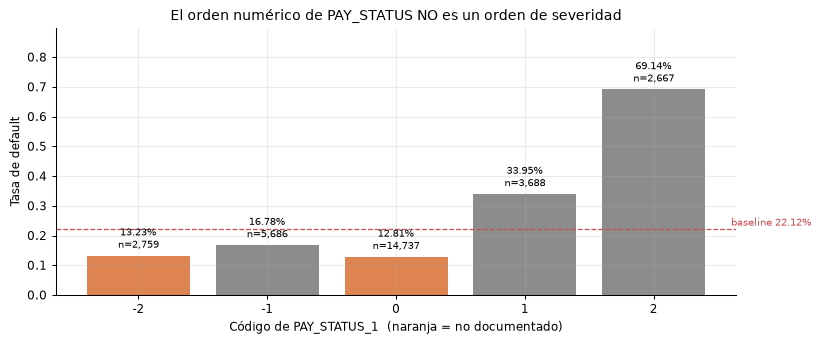

              default_rate   rows
PAY_STATUS_1                     
-2                   13.23   2759
-1                   16.78   5686
 0                   12.81  14737
 1                   33.95   3688
 2                   69.14   2667


In [7]:
default_by_code = (
    frame.groupby("PAY_STATUS_1")[schema.TARGET_COLUMN]
    .agg(["mean", "size"])
    .rename(columns={"mean": "default_rate", "size": "rows"})
)
low_zone = default_by_code.loc[default_by_code.index <= 2]
baseline = target.mean()

fig, ax = plt.subplots(figsize=(9.0, 3.8))
colors = [HIGHLIGHT if c in (-2, 0) else NEUTRAL for c in low_zone.index]
bars = ax.bar([str(c) for c in low_zone.index], low_zone["default_rate"], color=colors)
for bar, (rate, rows) in zip(bars, low_zone[["default_rate", "rows"]].to_numpy(), strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.015,
        f"{rate:.2%}\nn={int(rows):,}",
        ha="center",
        va="bottom",
        fontsize=8,
    )
ax.axhline(baseline, color=DEFAULT, linestyle="--", linewidth=1)
ax.text(
    len(low_zone) - 0.4,
    baseline + 0.012,
    f"baseline {baseline:.2%}",
    color=DEFAULT,
    fontsize=8,
)
ax.set_ylim(0, low_zone["default_rate"].max() * 1.30)
ax.set_xlabel("Código de PAY_STATUS_1  (naranja = no documentado)")
ax.set_ylabel("Tasa de default")
ax.set_title("El orden numérico de PAY_STATUS NO es un orden de severidad")
plt.show()

print(low_zone.assign(default_rate=lambda d: (100 * d["default_rate"]).round(2)).to_string())

**Lectura — visualización 4. Esta es la que decide la codificación de seis columnas.**

Si el orden numérico fuera un orden de severidad, las barras subirían de izquierda a
derecha. **No lo hacen.** El código `0` —que la fuente no documenta— tiene la tasa de
default *más baja* de la zona, por debajo del `-1` y del `-2`, que lo preceden en el orden
numérico. Recién a partir del `1` la escala se vuelve monótona y empinada.

Un modelo que tratara esta columna como numérica aprendería una monotonía **que no existe
en el dato**.

> **ADR-0004 §2, consecuencia directa y no negociable:** las seis columnas `PAY_STATUS_*`
> van a **one-hot encoding** y **nunca** a escalado numérico. El pipeline lo hace cumplir en
> `preprocessor.CATEGORICAL_COLUMNS`, y hay un test que se pone rojo si alguien las mueve
> a la rama numérica.

El gráfico también insinúa por qué el `0` es lo que el ADR dice que es: un cliente de
**crédito revolvente**, que usa la tarjeta, paga una parte y arrastra el resto **sin estar
en mora**. La visualización siguiente lo confirma con la medición que más separa.

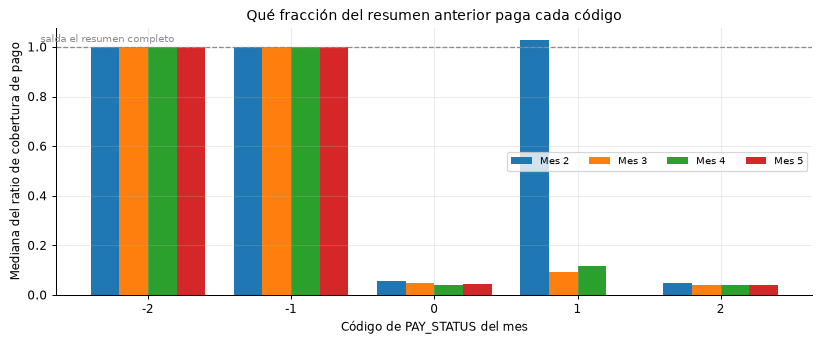

Mediana del ratio de cobertura:
     Mes 2   Mes 3   Mes 4   Mes 5
-2  1.0000  1.0000  1.0000  1.0000
-1  1.0000  1.0000  1.0000  1.0000
 0  0.0547  0.0469  0.0415  0.0439
 1  1.0264  0.0914  0.1156     NaN
 2  0.0481  0.0409  0.0390  0.0400

Filas detras de cada mediana:
    Mes 2  Mes 3  Mes 4  Mes 5
-2   3782   4085   4348   4546
-1   6050   5938   5687   5539
 0  15730  15764  16455  16947
 1     28      4      2      0
 2   3927   3819   3159   2626


In [8]:
derived = PaymentBehaviourFeatures().fit_transform(frame)
augmented = pd.concat([frame, derived], axis=1)

coverage = pd.DataFrame(
    {
        f"Mes {month}": augmented.groupby(f"PAY_STATUS_{month}")[f"PAYMENT_RATIO_M{month}"].median()
        for month in PAYMENT_RATIO_MONTHS
    }
)
coverage = coverage.loc[coverage.index <= 2]
coverage_rows = (
    pd.DataFrame(
        {
            f"Mes {month}": augmented[f"PAY_STATUS_{month}"].value_counts()
            for month in PAYMENT_RATIO_MONTHS
        }
    )
    .reindex(coverage.index)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(9.0, 3.8))
positions = np.arange(len(coverage.index))
width = 0.8 / coverage.shape[1]
for offset, column in enumerate(coverage.columns):
    ax.bar(positions + offset * width, coverage[column], width, label=column)
ax.set_xticks(positions + width * (coverage.shape[1] - 1) / 2)
ax.set_xticklabels([str(c) for c in coverage.index])
ax.axhline(1.0, color=NEUTRAL, linestyle="--", linewidth=1)
ax.text(-0.45, 1.02, "salda el resumen completo", color=NEUTRAL, fontsize=8)
ax.set_xlabel("Código de PAY_STATUS del mes")
ax.set_ylabel("Mediana del ratio de cobertura de pago")
ax.set_title("Qué fracción del resumen anterior paga cada código")
ax.legend(fontsize=8, ncol=4)
plt.show()

print("Mediana del ratio de cobertura:")
print(coverage.round(4).to_string())
print()
print("Filas detras de cada mediana:")
print(coverage_rows.to_string())

**Lectura — visualización 5.** El ratio de cobertura es lo abonado en un mes dividido por
el saldo del mes cronológicamente anterior: **qué fracción del resumen pagó realmente el
cliente**.

La separación es nítida y consistente en los cuatro meses calculables:

- Los códigos **`-1` y `-2` saldan el resumen completo** — su mediana se apoya en la línea
  del 1,0.
- El código **`0` paga una fracción positiva y pequeña**, de unas pocas centésimas.
- El código **`2` paga prácticamente nada**, que es lo que se espera de dos meses de mora.

Esa es la evidencia principal del **ADR-0004 §1**: `-2` es *ausencia de consumo* y `0` es
*crédito revolvente*. Un cliente que arrastra saldo pagando el mínimo no está en mora, está
financiándose — y eso explica que su tasa de default sea la más baja de la zona baja.

**El código `1` es el que hay que leer con cuidado, y vuelve a delatar al mes 1.** Su barra
se mueve de forma errática entre meses —en uno de ellos incluso salda el resumen completo—
y la tabla de conteos impresa debajo explica por qué: **detrás de esas medianas hay unas
pocas decenas de filas, y en un mes ninguna**. No es una medición sobre la que se pueda
concluir nada, y esa es exactamente la observación de la visualización 3 vista desde otro
lado: fuera del mes 1 el código `1` prácticamente no existe. Las medianas de los códigos
`-2`, `-1`, `0` y `2` se apoyan en miles o decenas de miles de filas cada una.

> **Nota de método.** Este gráfico usa la feature `PAYMENT_RATIO_M*` del propio pipeline,
> que aplica el **piso de denominador de 100 NT\$** del ADR-0005. El documento de evidencia
> que sostiene el ADR-0004 midió lo mismo con la regla anterior, `denominador > 0`, así que
> las cifras no coinciden al decimal — están advertidas con fecha en la cabecera de
> `docs/analysis/undocumented-codes-evidence.md`. La separación que sostiene la decisión es
> de dos órdenes de magnitud y no depende de esa diferencia.

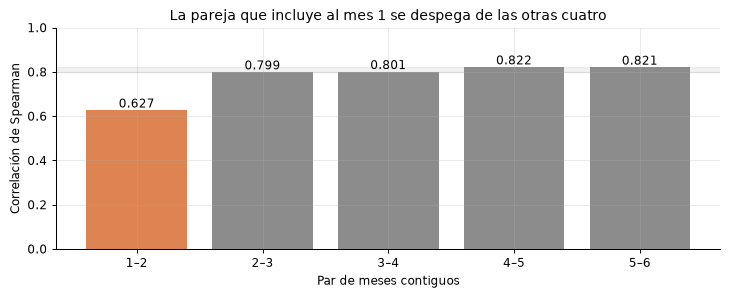

Pares sin el mes 1: min 0.799  max 0.822  amplitud 0.023
Pareja 1-2: 0.627  (0.172 por debajo de la mas baja de las otras)


In [9]:
pairs = [(m, m + 1) for m in range(1, 6)]
spearman_by_pair = pd.Series(
    {
        f"{a}–{b}": frame[f"PAY_STATUS_{a}"].corr(frame[f"PAY_STATUS_{b}"], method="spearman")
        for a, b in pairs
    }
)

fig, ax = plt.subplots(figsize=(8.0, 3.3))
colors = [HIGHLIGHT] + [NEUTRAL] * (len(spearman_by_pair) - 1)
bars = ax.bar(spearman_by_pair.index, spearman_by_pair, color=colors)
for bar, value in zip(bars, spearman_by_pair, strict=True):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:.3f}", ha="center")
others = spearman_by_pair.iloc[1:]
ax.axhspan(others.min(), others.max(), color=NEUTRAL, alpha=0.12)
ax.set_ylim(0, 1.0)
ax.set_xlabel("Par de meses contiguos")
ax.set_ylabel("Correlación de Spearman")
ax.set_title("La pareja que incluye al mes 1 se despega de las otras cuatro")
plt.show()

print(
    f"Pares sin el mes 1: min {others.min():.3f}  max {others.max():.3f}  "
    f"amplitud {others.max() - others.min():.3f}"
)
print(
    f"Pareja 1-2: {spearman_by_pair.iloc[0]:.3f}  "
    f"({others.min() - spearman_by_pair.iloc[0]:.3f} por debajo de la mas baja de las otras)"
)

**Lectura — visualización 6.** Segunda evidencia del **ADR-0004 §3**.

Las cuatro parejas que **no** involucran al mes 1 se agrupan en una banda estrechísima —la
franja gris—: entre ellas hay centésimas de diferencia. La pareja **1–2 cae claramente por
debajo** de todas.

Si las seis columnas midieran lo mismo en la misma escala, la correlación entre meses
contiguos no tendría por qué caer justo en la única pareja que cruza el mes 1. La caída
está donde la hipótesis la predijo.

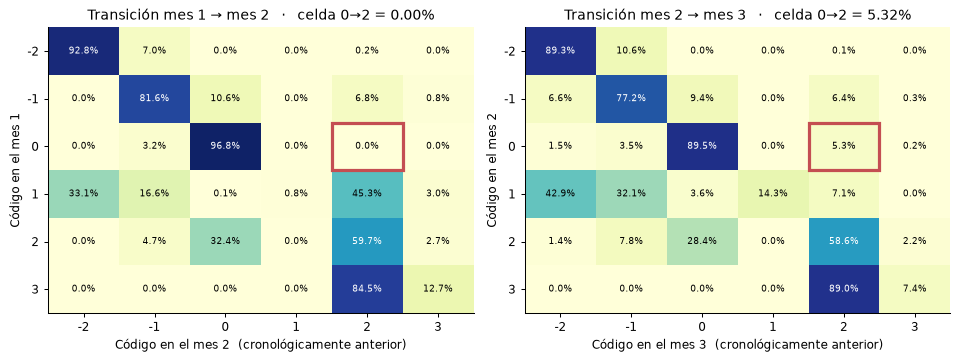

Matriz mes 1 -> mes 2: fila del codigo 0 envia 0.00% al codigo 2  (sobre 14,737 filas)
Matriz mes 2 -> mes 3: fila del codigo 0 envia 5.32% al codigo 2  (sobre 15,730 filas)
Matriz mes 3 -> mes 4: fila del codigo 0 envia 4.26% al codigo 2  (sobre 15,764 filas)
Matriz mes 4 -> mes 5: fila del codigo 0 envia 3.48% al codigo 2  (sobre 16,455 filas)
Matriz mes 5 -> mes 6: fila del codigo 0 envia 4.32% al codigo 2  (sobre 16,947 filas)


In [10]:
low_codes = [-2, -1, 0, 1, 2, 3]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
for ax, (a, b) in zip(axes, [(1, 2), (2, 3)], strict=True):
    subset = frame[frame[f"PAY_STATUS_{a}"].isin(low_codes)]
    matrix = (
        pd.crosstab(subset[f"PAY_STATUS_{a}"], subset[f"PAY_STATUS_{b}"], normalize="index")
        .reindex(index=low_codes, columns=low_codes)
        .fillna(0)
    )
    ax.imshow(matrix.to_numpy(), cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(low_codes)), [str(c) for c in low_codes])
    ax.set_yticks(range(len(low_codes)), [str(c) for c in low_codes])
    for row in range(len(low_codes)):
        for col in range(len(low_codes)):
            value = matrix.iat[row, col]
            ax.text(
                col,
                row,
                f"{value:.1%}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if value > 0.5 else "black",
            )
    cell = matrix.loc[0, 2]
    ax.add_patch(
        plt.Rectangle(
            (low_codes.index(2) - 0.5, low_codes.index(0) - 0.5),
            1,
            1,
            fill=False,
            edgecolor=DEFAULT,
            linewidth=2.5,
        )
    )
    ax.set_xlabel(f"Código en el mes {b}  (cronológicamente anterior)")
    ax.set_ylabel(f"Código en el mes {a}")
    ax.set_title(f"Transición mes {a} → mes {b}   ·   celda 0→2 = {cell:.2%}")
    ax.grid(False)
plt.show()

for a, b in [(m, m + 1) for m in range(1, 6)]:
    subset = frame[frame[f"PAY_STATUS_{a}"] == 0]
    share = (subset[f"PAY_STATUS_{b}"] == 2).mean()
    print(
        f"Matriz mes {a} -> mes {b}: fila del codigo 0 envia {share:.2%} al codigo 2  "
        f"(sobre {len(subset):,} filas)"
    )

**Lectura — visualización 7.** Tercera y más contundente evidencia del **ADR-0004 §3**.

La celda marcada en rojo es la misma en los dos paneles: qué proporción de los clientes con
código `0` en un mes tiene código `2` en el mes adyacente. En la matriz que cruza el mes 1
esa celda vale **exactamente cero**, sobre más de catorce mil filas. En la matriz vecina, y
en las otras tres que están impresas debajo, la misma celda vale un porcentaje pequeño pero
claramente distinto de cero.

**Un cero sobre catorce mil observaciones no es una muestra insuficiente: es una
imposibilidad estructural.** Algo en la construcción del mes 1 impide esa transición.

### La consecuencia, y su matiz medido

El ADR-0004 acota el alcance de esta decisión con honestidad: **la anomalía se concentra en
los códigos `1`, `0` y `-1`**. Los códigos iguales o mayores a `3` transitan de `k` a `k-1`
con probabilidad dominante en las cinco matrices por igual — la zona alta de la escala **sí**
es homogénea entre meses.

De ahí salen las dos reglas que gobiernan todas las features derivadas:

1. **Las features de trayectoria se construyen sobre los meses 2 a 6**, nunca sobre los seis.
2. **El mes 1 entra al modelo como variable aparte** — no se excluye: es la columna de
   estado de pago más asociada al target.

---

# 5 · Univariado — las colas que eligieron el escalador

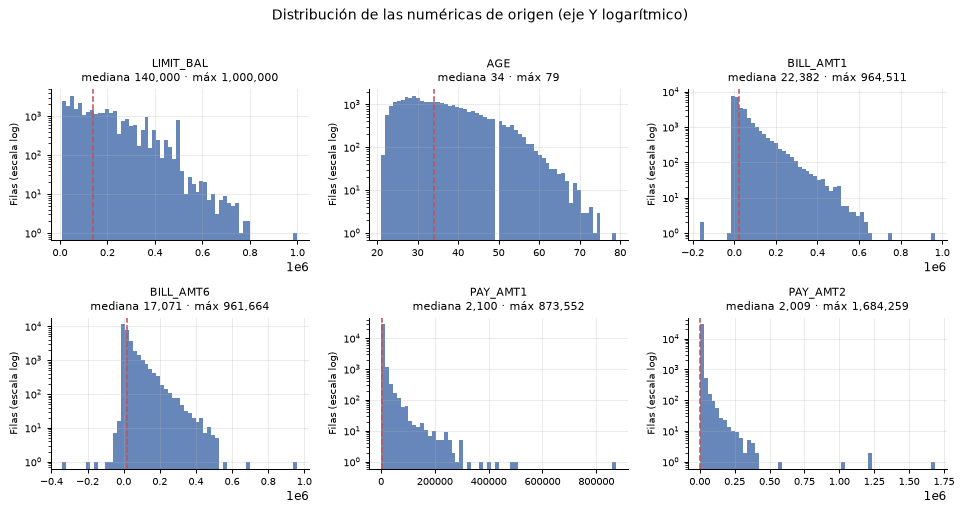

       LIMIT_BAL      AGE  BILL_AMT1  BILL_AMT6  PAY_AMT1   PAY_AMT2
count    30000.0  30000.0    30000.0    30000.0   30000.0    30000.0
mean    167484.3     35.5    51223.3    38871.8    5663.6     5921.2
std     129747.7      9.2    73635.9    59554.1   16563.3    23040.9
min      10000.0     21.0  -165580.0  -339603.0       0.0        0.0
50%     140000.0     34.0    22381.5    17071.0    2100.0     2009.0
95%     430000.0     53.0   201203.0   161912.0   18428.2    19004.3
99%     500000.0     60.0   350110.7   279505.1   66522.2    76651.0
max    1000000.0     79.0   964511.0   961664.0  873552.0  1684259.0


In [11]:
to_plot = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT6", "PAY_AMT1", "PAY_AMT2"]

fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.4))
for ax, column in zip(axes.ravel(), to_plot, strict=True):
    values = frame[column]
    ax.hist(values, bins=60, color=NO_DEFAULT, alpha=0.85)
    ax.axvline(values.median(), color=DEFAULT, linestyle="--", linewidth=1.2)
    ax.set_title(
        f"{column}\nmediana {values.median():,.0f} · máx {values.max():,.0f}", fontsize=8.5
    )
    ax.set_yscale("log")
    ax.set_ylabel("Filas (escala log)", fontsize=7.5)
    ax.tick_params(labelsize=7.5)
fig.suptitle("Distribución de las numéricas de origen (eje Y logarítmico)", y=1.02)
plt.show()

print(frame[to_plot].describe(percentiles=[0.5, 0.95, 0.99]).round(1).to_string())

**Lectura — visualización 8.** El eje Y está en escala logarítmica **porque en escala
lineal estos histogramas no se leen**: la masa se apila contra el borde izquierdo y la cola
se vuelve invisible.

`LIMIT_BAL` y `AGE` son razonablemente ordinarias. Los saldos (`BILL_AMT*`) ya tienen cola
derecha. Los **pagos (`PAY_AMT*`) son otra cosa**: la mediana está en unos pocos miles de
NT\$ y el máximo en cientos de miles. Entre la mediana y el máximo hay dos órdenes de
magnitud, y casi todas las filas viven en el primer tramo.

Eso no es un error del dato — es cómo se comporta un pago de tarjeta. Pero tiene una
consecuencia directa sobre cómo hay que escalar, y la siguiente visualización la mide.

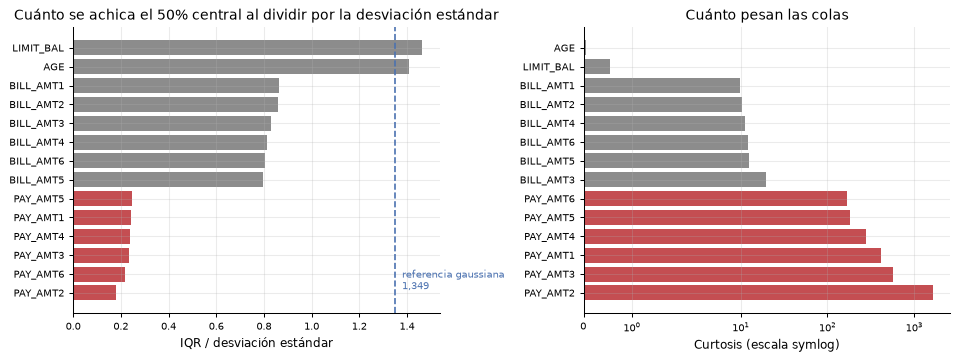

             skew  kurtosis  iqr_over_std
PAY_AMT2   30.454  1641.632         0.181
PAY_AMT6   10.641   167.161         0.218
PAY_AMT3   17.217   564.311         0.234
PAY_AMT4   12.905   277.334         0.237
PAY_AMT1   14.668   415.255         0.242
PAY_AMT5   11.127   180.064         0.247
BILL_AMT5   2.876    12.306         0.797
BILL_AMT6   2.847    12.271         0.805
BILL_AMT4   2.822    11.309         0.811
BILL_AMT3   3.088    19.783         0.829
BILL_AMT2   2.705    10.303         0.857
BILL_AMT1   2.664     9.806         0.863
AGE         0.732     0.044         1.410
LIMIT_BAL   0.993     0.536         1.464


In [12]:
source_numeric = list(NUMERIC_SOURCE_COLUMNS)
stats = pd.DataFrame(
    {
        "skew": frame[source_numeric].skew(),
        "kurtosis": frame[source_numeric].kurtosis(),
        "iqr_over_std": [
            (frame[c].quantile(0.75) - frame[c].quantile(0.25)) / frame[c].std(ddof=0)
            for c in source_numeric
        ],
    }
)
GAUSSIAN_IQR_OVER_STD = 1.349

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

order = stats.sort_values("iqr_over_std")
colors = [DEFAULT if v < 0.5 else NEUTRAL for v in order["iqr_over_std"]]
axes[0].barh(order.index, order["iqr_over_std"], color=colors)
axes[0].axvline(GAUSSIAN_IQR_OVER_STD, color=NO_DEFAULT, linestyle="--", linewidth=1.3)
axes[0].text(
    GAUSSIAN_IQR_OVER_STD + 0.03, 0.2, "referencia gaussiana\n1,349", fontsize=7.5, color=NO_DEFAULT
)
axes[0].set_xlabel("IQR / desviación estándar")
axes[0].set_title("Cuánto se achica el 50% central al dividir por la desviación estándar")
axes[0].tick_params(labelsize=7.5)

kurt = stats.sort_values("kurtosis", ascending=False)
axes[1].barh(
    kurt.index, kurt["kurtosis"], color=[DEFAULT if v > 50 else NEUTRAL for v in kurt["kurtosis"]]
)
axes[1].set_xscale("symlog")
axes[1].set_xlabel("Curtosis (escala symlog)")
axes[1].set_title("Cuánto pesan las colas")
axes[1].tick_params(labelsize=7.5)
plt.show()

print(stats.sort_values("iqr_over_std").round(3).to_string())

**Lectura — visualización 9. Esta es la medición que eligió `RobustScaler`.**

`IQR / desviación estándar` mide **qué le pasa a la zona donde el dato realmente vive**
cuando se divide por la desviación estándar. Para una gaussiana vale 1,349, la línea
punteada azul. Las barras rojas están muy por debajo: en esas columnas la desviación
estándar **es un estadístico de sus outliers**, no del dato, porque su curtosis está en los
cientos o los miles (panel derecho).

La consecuencia es concreta. Con `StandardScaler`, el 50% central de `PAY_AMT2` quedaría
comprimido en una banda **un orden de magnitud más angosta** que la de otra columna del
mismo dataset. Un modelo regularizado penalizaría su coeficiente mucho más para la misma
señal real — que es exactamente lo que escalar debía evitar.

`RobustScaler` divide por el rango intercuartílico, que la cola no mueve, así que la banda
central queda en 1,0 para todas. **El costo se declara y no se esconde:** los valores
extremos llegan más lejos que con `StandardScaler`. El pipeline compensa esa cola donde más
duele —los ratios de pago— con un recorte por percentil, y **no** la compensa en los
`PAY_AMT*`, que conservan su cola a propósito.

---

# 6 · Bivariado — tasa de default por segmento

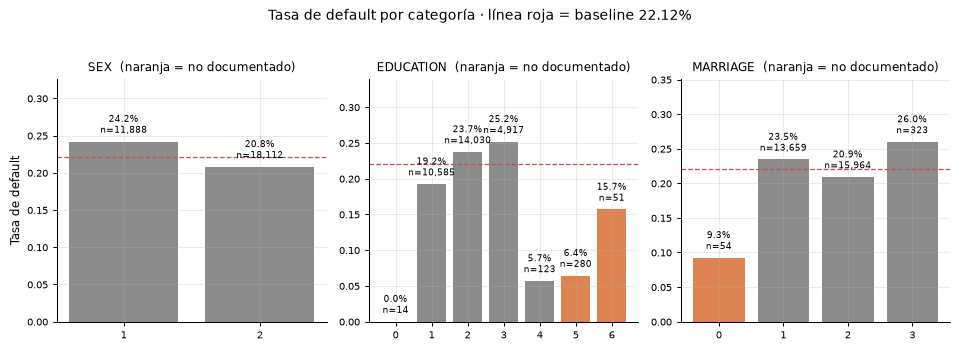

In [13]:
demographics = ["SEX", "EDUCATION", "MARRIAGE"]
documented_levels = {c: sorted(schema.CATEGORICAL_LEVELS[c]) for c in demographics}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
for ax, column in zip(axes, demographics, strict=True):
    grouped = frame.groupby(column)[schema.TARGET_COLUMN].agg(["mean", "size"])
    colors = [
        HIGHLIGHT if level not in documented_levels[column] else NEUTRAL for level in grouped.index
    ]
    bars = ax.bar([str(level) for level in grouped.index], grouped["mean"], color=colors)
    for bar, (rate, rows) in zip(bars, grouped[["mean", "size"]].to_numpy(), strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            rate + 0.008,
            f"{rate:.1%}\nn={int(rows):,}",
            ha="center",
            va="bottom",
            fontsize=7,
        )
    ax.axhline(baseline, color=DEFAULT, linestyle="--", linewidth=1)
    ax.set_ylim(0, max(grouped["mean"].max() * 1.35, baseline * 1.4))
    ax.set_title(f"{column}  (naranja = no documentado)", fontsize=9)
    ax.set_ylabel("Tasa de default" if column == "SEX" else "")
    ax.tick_params(labelsize=8)
fig.suptitle(f"Tasa de default por categoría · línea roja = baseline {baseline:.2%}", y=1.04)
plt.show()

**Lectura — visualización 10. Acá se ve por qué `EDUCATION` y `MARRIAGE` se resuelven
distinto, y no es una inconsistencia.**

En **`EDUCATION`**, los códigos no documentados (naranja) se parecen al nivel `4`, que la
fuente declara como *"otros"*: todos muy por debajo del baseline y lejos de los niveles
educativos ordinarios. **Se alinean con el nivel residual**, así que colapsarlos sobre el
`4` los pone donde la medición los ubica. Eso hace el paso `education` del pipeline.

En **`MARRIAGE`**, el código no documentado `0` está por debajo de **los tres** niveles
declarados, incluido el *"otros"* de su propia columna, que es varias veces más riesgoso.
**No se alinea con nada.** Colapsarlo hacia "otros" introduciría un sesgo de dirección
conocida, así que se conserva como nivel propio.

> **ADR-0004 §4 y §5.** Aplicar la misma regla a las dos columnas sería consistencia de
> forma a cambio de exactitud. Con 54 filas la estimación de `MARRIAGE = 0` es imprecisa y
> el ADR lo declara; pero la imprecisión no vuelve indiferente la elección.

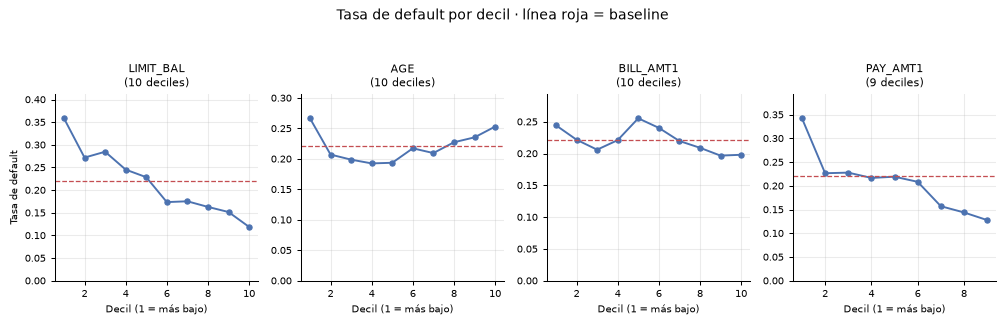

LIMIT_BAL   0.358  0.272  0.285  0.245  0.229  0.174  0.175  0.163  0.152  0.119
AGE         0.267  0.207  0.199  0.193  0.194  0.217  0.210  0.227  0.235  0.253
BILL_AMT1   0.244  0.222  0.206  0.221  0.255  0.240  0.220  0.209  0.197  0.198
PAY_AMT1    0.342  0.226  0.228  0.217  0.219  0.208  0.157  0.144  0.128


In [14]:
decile_columns = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

fig, axes = plt.subplots(1, 4, figsize=(11.0, 3.3))
for ax, column in zip(axes, decile_columns, strict=True):
    deciles = pd.qcut(frame[column], 10, labels=False, duplicates="drop")
    rate = frame.groupby(deciles)[schema.TARGET_COLUMN].mean()
    ax.plot(rate.index + 1, rate, marker="o", color=NO_DEFAULT, markersize=4)
    ax.axhline(baseline, color=DEFAULT, linestyle="--", linewidth=1)
    ax.set_title(f"{column}\n({len(rate)} deciles)", fontsize=8.5)
    ax.set_xlabel("Decil (1 = más bajo)", fontsize=8)
    ax.set_ylabel("Tasa de default" if column == "LIMIT_BAL" else "", fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.set_ylim(0, max(rate.max() * 1.15, baseline * 1.2))
fig.suptitle("Tasa de default por decil · línea roja = baseline", y=1.05)
plt.show()

for column in decile_columns:
    deciles = pd.qcut(frame[column], 10, labels=False, duplicates="drop")
    rate = frame.groupby(deciles)[schema.TARGET_COLUMN].mean()
    print(f"{column:<11} " + "  ".join(f"{value:.3f}" for value in rate))

**Lectura — visualización 11.** Cuatro lecturas, una por panel:

- **`LIMIT_BAL`** es la relación más fuerte de las cuatro: la tasa cae de forma casi
  monótona del primer decil al último —hay un único escalón que la rompe, y es pequeño—, y
  entre extremos la diferencia es de un factor de tres. La dirección es la esperable, y por
  eso conviene tenerla presente: el cupo alto **ya es el resultado de una decisión de riesgo
  previa del emisor**, así que parte de lo que este dataset "sabe" es lo que el banco ya
  sabía.
- **`AGE`** dibuja una U suave: los deciles extremos incumplen algo más que los centrales.
- **`BILL_AMT1`** es sorprendentemente plana. El **monto** del saldo por sí solo casi no
  ordena riesgo, lo cual es una razón concreta para construir la utilización: 40.000 NT\$
  de saldo significan cosas opuestas con cupo de 50.000 o de 500.000.
- **`PAY_AMT1`** baja con el monto pagado, con el primer decil bien por encima del resto.

Ninguna de las cuatro se acerca al poder que muestran las columnas de estado de pago. Es la
primera señal a favor de la hipótesis principal del proyecto, y **solo una señal**: el poder
predictivo se mide en la fase de modelado, no acá.

---

# 7 · Correlaciones entre las numéricas de origen

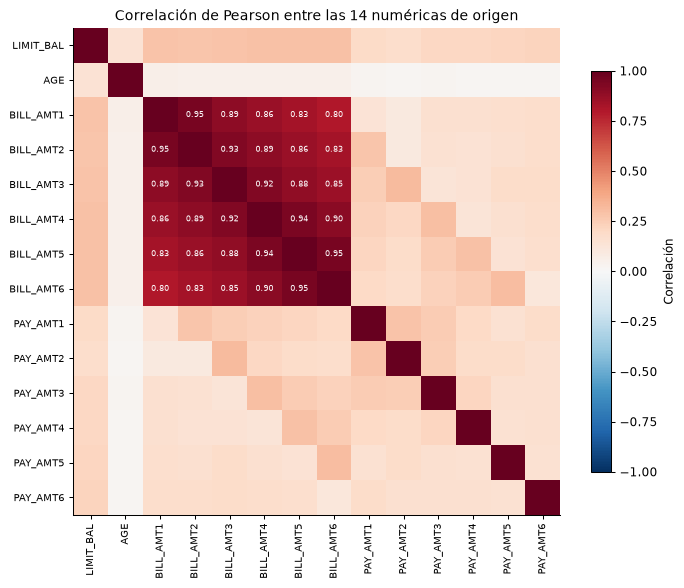

Pares con |correlacion| >= 0.90:
BILL_AMT1  BILL_AMT2    0.951
BILL_AMT5  BILL_AMT6    0.946
BILL_AMT4  BILL_AMT5    0.940
BILL_AMT2  BILL_AMT3    0.928
BILL_AMT3  BILL_AMT4    0.924
BILL_AMT4  BILL_AMT6    0.901


In [15]:
corr = frame[source_numeric].corr()

fig, ax = plt.subplots(figsize=(7.6, 6.4))
image = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(corr)), corr.index, fontsize=7.5)
for row in range(len(corr)):
    for col in range(len(corr)):
        value = corr.iat[row, col]
        if row != col and abs(value) >= 0.5:
            ax.text(
                col,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=6.5,
                color="white" if abs(value) > 0.75 else "black",
            )
ax.set_title("Correlación de Pearson entre las 14 numéricas de origen")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="Correlación")
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Pares con |correlacion| >= 0.90:")
print(upper[upper.abs() >= 0.90].sort_values(ascending=False).round(3).to_string())

**Lectura — visualización 12.** El bloque rojo intenso arriba a la izquierda es el de los
saldos: **los seis `BILL_AMT*` están fortísimamente correlacionados entre sí**, y los pares
de meses adyacentes son los más altos de todos. Tiene sentido de negocio: el saldo de un mes
es en buena medida el del mes anterior más el consumo nuevo.

Los pagos (`PAY_AMT*`) se correlacionan mucho menos entre sí, y `LIMIT_BAL` y `AGE` son
prácticamente independientes de todo lo demás.

**Acá no se decide nada, y es deliberado.** La multicolinealidad afecta a unos modelos y no
a otros: infla la varianza de los coeficientes de una regresión lineal y deja indiferente a
un modelo de árboles. Eliminar columnas ahora sería tomar del lado del dato una decisión que
pertenece al lado del modelo. Queda **registrado** como algo a mirar en la fase 2, con VIF y
con la métrica de decisión al lado.

---

# 8 · Las features derivadas

Ninguna de las variables que pone a prueba la hipótesis principal viene en la fuente. La
fuente trae códigos, saldos y pagos; **cuánto del cupo se está usando, si eso sube o baja,
qué fracción del resumen se paga y cuánto lleva el cliente en mora hay que derivarlo.**

El transformador `PaymentBehaviourFeatures` —ya aplicado más arriba para la visualización 5—
produce **22 columnas**. Es un paso de `Pipeline` de sklearn y no una función suelta,
porque el notebook, el script de entrenamiento y la API tienen que consumir el mismo objeto.

In [16]:
print(f"Features derivadas: {len(FEATURE_NAMES)}")
print(f"Bloque homogéneo (ADR-0004 §3): meses {sorted(BLOCK_MONTHS)}")
print(f"Ratios de pago construidos: {list(PAYMENT_RATIO_FEATURES)}")
print()
derived.describe().T[["count", "mean", "50%", "max"]].round(3)

Features derivadas: 22
Bloque homogéneo (ADR-0004 §3): meses [2, 3, 4, 5, 6]
Ratios de pago construidos: ['PAYMENT_RATIO_M2', 'PAYMENT_RATIO_M3', 'PAYMENT_RATIO_M4', 'PAYMENT_RATIO_M5']



,count,mean,50%,max
UTILIZATION_M2,30000.0,0.411,0.296,6.380
UTILIZATION_M3,30000.0,0.392,0.273,10.689
UTILIZATION_M4,30000.0,0.360,0.242,5.147
UTILIZATION_M5,30000.0,0.333,0.212,4.936
UTILIZATION_M6,30000.0,0.319,0.185,3.886
UTILIZATION_TREND_M2_M6,30000.0,0.024,0.001,1.085
PAYMENT_RATIO_M2,26405.0,0.365,0.077,72.749
PAYMENT_RATIO_M3,26067.0,0.344,0.062,68.027
PAYMENT_RATIO_M4,25754.0,0.343,0.052,129.705
PAYMENT_RATIO_M5,25219.0,0.382,0.056,447.735


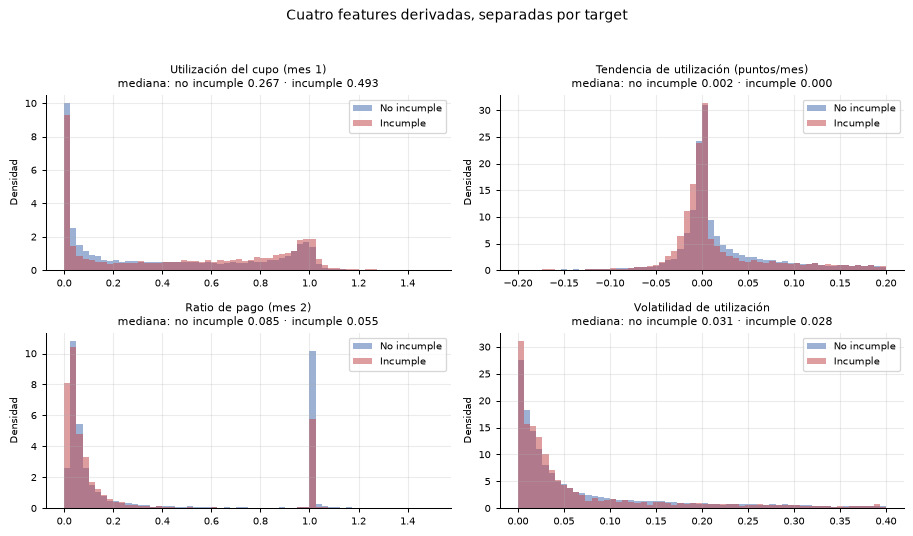

                              mediana | no incumple  mediana | incumple
UTILIZATION_MOST_RECENT_M1                   0.2675              0.4929
UTILIZATION_TREND_M2_M6                      0.0020              0.0000
PAYMENT_RATIO_M2                             0.0855              0.0555
UTILIZATION_VOLATILITY_M2_M6                 0.0311              0.0276

Proporcion que salda el resumen (ratio de pago entre 0,98 y 1,05):
  no incumple: 26.16%  (sobre 20,608 filas calculables)
  incumple   : 14.80%  (sobre 5,797 filas calculables)


In [17]:
show = [
    ("UTILIZATION_MOST_RECENT_M1", "Utilización del cupo (mes 1)", (0, 1.5)),
    ("UTILIZATION_TREND_M2_M6", "Tendencia de utilización (puntos/mes)", (-0.2, 0.2)),
    ("PAYMENT_RATIO_M2", "Ratio de pago (mes 2)", (0, 1.5)),
    ("UTILIZATION_VOLATILITY_M2_M6", "Volatilidad de utilización", (0, 0.4)),
]

fig, axes = plt.subplots(2, 2, figsize=(10.0, 5.6))
for ax, (column, label, span) in zip(axes.ravel(), show, strict=True):
    for value, name, color in ((0, "No incumple", NO_DEFAULT), (1, "Incumple", DEFAULT)):
        series = augmented.loc[augmented[schema.TARGET_COLUMN] == value, column].dropna()
        ax.hist(series, bins=60, range=span, density=True, alpha=0.55, color=color, label=name)
    medians = augmented.groupby(schema.TARGET_COLUMN)[column].median()
    ax.set_title(
        f"{label}\nmediana: no incumple {medians.loc[0]:.3f} · incumple {medians.loc[1]:.3f}",
        fontsize=8.5,
    )
    ax.set_ylabel("Densidad", fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.legend(fontsize=7.5)
fig.suptitle("Cuatro features derivadas, separadas por target", y=1.03)
plt.show()

summary = pd.DataFrame(
    {column: augmented.groupby(schema.TARGET_COLUMN)[column].median() for column, _, _ in show}
).T
summary.columns = ["mediana | no incumple", "mediana | incumple"]
print(summary.round(4).to_string())

settled = augmented["PAYMENT_RATIO_M2"].between(0.98, 1.05)
print()
print("Proporcion que salda el resumen (ratio de pago entre 0,98 y 1,05):")
for value, label in ((0, "no incumple"), (1, "incumple   ")):
    mask = (augmented[schema.TARGET_COLUMN] == value) & augmented["PAYMENT_RATIO_M2"].notna()
    print(f"  {label}: {settled[mask].mean():.2%}  (sobre {int(mask.sum()):,} filas calculables)")

**Lectura — visualización 13.** Las cuatro se comportan de forma distinta entre sí, y **dos
de ellas no hacen lo que la intuición diría**. Las medianas impresas debajo del gráfico son
la referencia:

- **Utilización del mes 1** es la que más separa de las cuatro: la mediana de los que
  incumplen casi duplica a la de los que no. Un cliente pegado al techo del cupo se quedó
  sin margen, que es la forma habitual del estrés financiero antes de un impago.
- **Ratio de pago del mes 2**: la mediana de los que no incumplen es más alta, pero lo
  interesante está en el pico de la derecha. La proporción de clientes que **saldan el
  resumen** —ratio en el entorno de 1,0— es cerca del doble entre los que no incumplen. Es
  la separación que el ADR-0004 ya había medido, ahora vista contra el target.
- **Tendencia de utilización**: las dos medianas son prácticamente **iguales**. Por sí sola,
  y en la mediana, esta feature casi no distingue. No es un motivo para tirarla —el nivel y
  la tendencia responden preguntas distintas, y una feature puede aportar en interacción con
  otras—, pero sí es un motivo para **no venderla como hallazgo**.
- **Volatilidad de utilización**: los que incumplen son, si acaso, **algo menos** volátiles.
  Va en contra de la intuición ingenua de *"errático = riesgoso"*, y encaja con la lectura
  del ADR-0004: un revolvente estable arrastra saldo mes a mes sin oscilar, y arrastrar
  saldo es justamente el perfil de riesgo.

**Que una distribución se corra no significa que la feature aporte, y que no se corra no
significa que sobre.** Lo primero se mide con la métrica de decisión en la fase 2; lo
segundo también. Este gráfico ordena las hipótesis, no las resuelve.

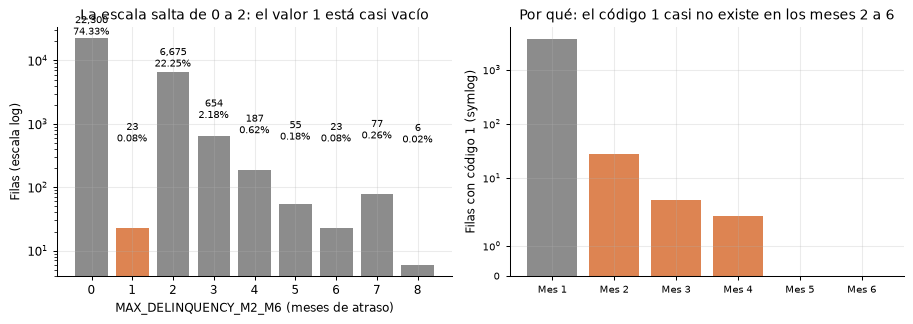

Filas con MAX_DELINQUENCY == 1: 23 (0.08%)
Filas con MAX_DELINQUENCY == 0: 22,300
Filas con MAX_DELINQUENCY == 2: 6,675


In [18]:
max_delinquency = derived["MAX_DELINQUENCY_M2_M6"].value_counts().sort_index()
code_one_block = pd.Series(
    {f"Mes {m}": int((frame[f"PAY_STATUS_{m}"] == 1).sum()) for m in range(1, 7)}
)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6))
colors = [HIGHLIGHT if value == 1 else NEUTRAL for value in max_delinquency.index]
bars = axes[0].bar([str(v) for v in max_delinquency.index], max_delinquency, color=colors)
for bar, value in zip(bars, max_delinquency, strict=True):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + max_delinquency.max() * 0.02,
        f"{value:,}\n{value / len(frame):.2%}",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )
axes[0].set_yscale("log")
axes[0].set_xlabel("MAX_DELINQUENCY_M2_M6 (meses de atraso)")
axes[0].set_ylabel("Filas (escala log)")
axes[0].set_title("La escala salta de 0 a 2: el valor 1 está casi vacío")

axes[1].bar(code_one_block.index, code_one_block, color=[NEUTRAL] + [HIGHLIGHT] * 5)
axes[1].set_yscale("symlog")
axes[1].set_ylabel("Filas con código 1 (symlog)")
axes[1].set_title("Por qué: el código 1 casi no existe en los meses 2 a 6")
axes[1].tick_params(labelsize=8)
plt.show()

print(
    f"Filas con MAX_DELINQUENCY == 1: {max_delinquency.get(1, 0):,} "
    f"({max_delinquency.get(1, 0) / len(frame):.2%})"
)
print(f"Filas con MAX_DELINQUENCY == 0: {max_delinquency.get(0, 0):,}")
print(f"Filas con MAX_DELINQUENCY == 2: {max_delinquency.get(2, 0):,}")

**Lectura — visualización 14. Es el ADR-0004 reapareciendo desde otro ángulo, y no lo
buscábamos acá.**

`MAX_DELINQUENCY_M2_M6` es el peor atraso alcanzado en el bloque homogéneo, en meses. Su
escala **salta de 0 a 2**: el valor `1` existe en un puñado ínfimo de filas mientras que el
`0` y el `2` concentran casi todo.

El panel derecho da la causa inmediata: la feature se construye sobre los meses 2 a 6, y en
esos meses **el código `1` casi no existe**. No es un defecto de la feature ni un error de
cálculo — es la anomalía de escala del §3 del ADR-0004 propagándose, con exactitud, hasta
una variable derivada tres pasos más abajo.

Vale la pena señalar lo que esto dice del método: la anomalía se detectó midiendo códigos
crudos, se registró en un ADR, y aparece sola en una feature derivada. **Si no se hubiera
medido antes, acá parecería un bug.**

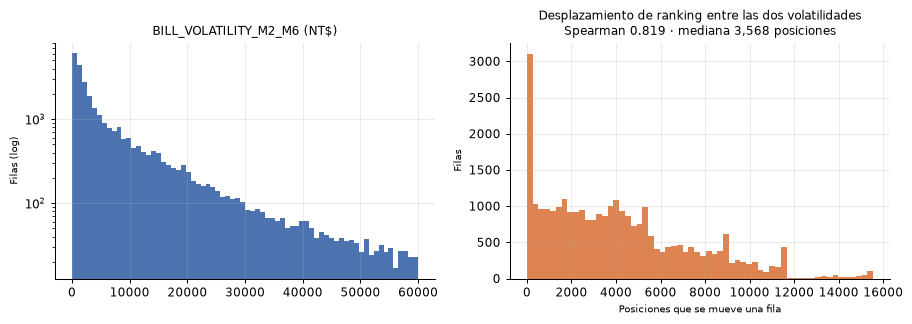

Decil mas volatil segun cada una: comparten 1,145 de 3,000 filas (38.2%)


In [19]:
volatilities = derived[["BILL_VOLATILITY_M2_M6", "UTILIZATION_VOLATILITY_M2_M6"]]
ranks = volatilities.rank(ascending=False)
spearman_pair = volatilities.corr(method="spearman").iloc[0, 1]
top_decile = int(len(frame) * 0.1)
overlap = len(
    set(volatilities.iloc[:, 0].nlargest(top_decile).index)
    & set(volatilities.iloc[:, 1].nlargest(top_decile).index)
)

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.6))
axes[0].hist(volatilities["BILL_VOLATILITY_M2_M6"], bins=70, range=(0, 60_000), color=NO_DEFAULT)
axes[0].set_yscale("log")
axes[0].set_title("BILL_VOLATILITY_M2_M6 (NT$)", fontsize=9)
axes[0].set_ylabel("Filas (log)", fontsize=8)

shift = (ranks.iloc[:, 0] - ranks.iloc[:, 1]).abs()
axes[1].hist(shift, bins=60, color=HIGHLIGHT)
axes[1].set_title(
    f"Desplazamiento de ranking entre las dos volatilidades\n"
    f"Spearman {spearman_pair:.3f} · mediana {shift.median():,.0f} posiciones",
    fontsize=9,
)
axes[1].set_xlabel("Posiciones que se mueve una fila", fontsize=8)
axes[1].set_ylabel("Filas", fontsize=8)
plt.show()

print(
    f"Decil mas volatil segun cada una: comparten {overlap:,} de {top_decile:,} filas "
    f"({overlap / top_decile:.1%})"
)

**Lectura — visualización 15.** El proyecto construye **dos** medidas de volatilidad del
saldo: una en NT\$ y otra normalizada por el cupo. La razón es que la de NT\$ **está
confundida con el tamaño del cupo**: un cliente con cupo de 500.000 cuyo saldo oscila 50.000
y otro con cupo de 50.000 cuyo saldo oscila 5.000 tienen el mismo hábito, y la versión en
NT\$ ordena al primero como diez veces más errático.

El panel derecho responde la pregunta obvia —*¿no serán la misma columna con otras
unidades?*—. **No lo son.** Ordenan parecido pero no igual, y el decil más volátil según
cada una comparte bastante menos de la mitad de sus filas.

**Cuál de las dos sobrevive no se decide acá.** Se decide en la fase de modelado, midiendo.
Conservar las dos hasta entonces es preferir evidencia a argumento.

---

# 9 · El pipeline completo

Entre las 24 columnas canónicas y la matriz que consume un modelo hay **un único objeto
`Pipeline`**, que devuelve `build_preprocessor()`. El notebook, el script de entrenamiento y
la API cargan **ese mismo artefacto**.

La razón está en la sección 6.3 de `docs/METHODOLOGY.md`: dos implementaciones de la misma
aritmética divergen, y la divergencia no da síntoma hasta producción — todo verde en el
notebook, predicciones basura en la API.

In [20]:
pipeline = build_preprocessor()
matrix = pipeline.fit_transform(frame)
names = list(pipeline.get_feature_names_out())

print(f"Matriz final: {matrix.shape[0]:,} filas x {matrix.shape[1]} columnas")
print(f"Nombres coinciden con las columnas: {names == list(matrix.columns)}")
print(f"Valores faltantes en la matriz: {int(matrix.isna().sum().sum())}")
print(f"Target presente en la matriz: {schema.TARGET_COLUMN in matrix.columns}")
print()
print("Topes de recorte aprendidos en fit (percentil 99,5):")
for column, bound in learned_parameters(pipeline)["clip"].items():
    print(f"  {column:<20} <= {bound:.4f}")
print()
constant = [n for n in names if matrix[n].nunique(dropna=False) == 1]
print(f"Columnas constantes: {len(constant)} -> {constant}")

Matriz final: 30,000 filas x 110 columnas
Nombres coinciden con las columnas: True
Valores faltantes en la matriz: 0
Target presente en la matriz: False

Topes de recorte aprendidos en fit (percentil 99,5):
  PAYMENT_RATIO_M2     <= 2.0000
  PAYMENT_RATIO_M3     <= 2.0000
  PAYMENT_RATIO_M4     <= 2.0004
  PAYMENT_RATIO_M5     <= 1.9984

Columnas constantes: 1 -> ['UTILIZATION_NOT_COMPUTABLE']


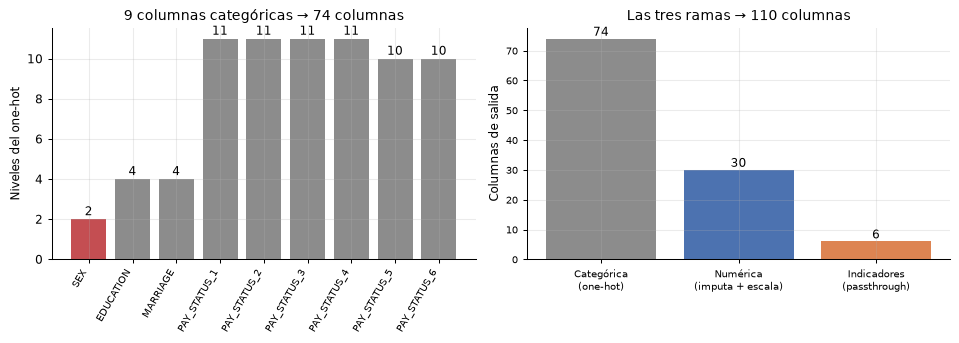

SEX              2 -> [1, 2]
EDUCATION        4 -> [1, 2, 3, 4]
MARRIAGE         4 -> [0, 1, 2, 3]
PAY_STATUS_1    11 -> [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_STATUS_2    11 -> [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_STATUS_3    11 -> [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_STATUS_4    11 -> [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
PAY_STATUS_5    10 -> [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]
PAY_STATUS_6    10 -> [-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


In [21]:
encoder = pipeline.named_steps["columns"].named_transformers_["categorical"]
levels = pd.Series(
    {
        column: len(cats)
        for column, cats in zip(CATEGORICAL_COLUMNS, encoder.categories_, strict=True)
    }
)
branch_sizes = pd.Series(
    {
        "Categórica\n(one-hot)": int(levels.sum()),
        "Numérica\n(imputa + escala)": len(NUMERIC_COLUMNS),
        "Indicadores\n(passthrough)": len(INDICATOR_COLUMNS),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
colors = [DEFAULT if v == levels.min() else NEUTRAL for v in levels]
bars = axes[0].bar(levels.index, levels, color=colors)
for bar, value in zip(bars, levels, strict=True):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value + 0.2, str(value), ha="center")
axes[0].set_xticks(range(len(levels)), levels.index, rotation=60, ha="right", fontsize=7.5)
axes[0].set_ylabel("Niveles del one-hot")
axes[0].set_title(f"9 columnas categóricas → {int(levels.sum())} columnas")

bars = axes[1].bar(branch_sizes.index, branch_sizes, color=[NEUTRAL, NO_DEFAULT, HIGHLIGHT])
for bar, value in zip(bars, branch_sizes, strict=True):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value + 1, str(value), ha="center")
axes[1].set_ylabel("Columnas de salida")
axes[1].set_title(f"Las tres ramas → {matrix.shape[1]} columnas")
axes[1].tick_params(labelsize=8)
plt.show()

for column, cats in zip(CATEGORICAL_COLUMNS, encoder.categories_, strict=True):
    print(f"{column:<15} {len(cats):>2} -> {sorted(int(c) for c in cats)}")

**Lectura — visualización 16.** El one-hot expande nueve columnas categóricas a decenas.
Es el costo que el **ADR-0004 §2** aceptó explícitamente a cambio de no codificar un orden
falso: *un espacio más grande es un problema de eficiencia, y una monotonía inventada es un
problema de corrección*.

### Por qué `PAY_STATUS_5` y `PAY_STATUS_6` producen un nivel menos

Las barras rojas del panel izquierdo son esas dos columnas, y la razón está impresa debajo
del gráfico: **les falta el código `1`**. No es que el one-hot lo haya descartado — es que
esas dos columnas **no contienen ni una sola fila con código `1`** en todo el archivo.

Es la visualización 3 volviendo por tercera vez: el código `1` está concentrado en el mes 1
y se desvanece hacia atrás en el tiempo hasta desaparecer del todo en los dos meses más
viejos. El one-hot lo vuelve visible **en la forma de la matriz**, sin que nadie lo pidiera.

> **Consecuencia práctica que hay que tener presente en la fase 2.** El pipeline usa
> `handle_unknown="ignore"`: un nivel ausente del fold de entrenamiento se codifica como
> todo ceros en vez de romper. No es laxitud — con 5 folds estratificados sobre este archivo
> hay folds cuyo entrenamiento no ve algún código raro pero **documentado**, y
> `handle_unknown="error"` haría caer la validación cruzada del propio proyecto sobre datos
> legítimos. El fallo ruidoso ante una categoría verdaderamente desconocida sigue existiendo
> y vive en el **validador**, en la puerta de entrada.

### Los faltantes: qué se imputa y qué información se conserva

Las features producen valores faltantes **por diseño**: cuando un denominador no supera el
piso de 100 NT\$ del ADR-0005, el ratio no es cero — es *desconocido*, y escribir un número
ahí convertiría una ausencia en un hecho de negocio falso.

La matriz final, en cambio, no tiene faltantes. La celda de abajo verifica que **la
información no se perdió al imputar**.

In [22]:
pairs = {
    ratio: f"{ratio.replace('PAYMENT_RATIO', 'PAYMENT_RATIO_NOT_COMPUTABLE')}"
    for ratio in PAYMENT_RATIO_FEATURES
}
check = pd.DataFrame(
    {
        "no calculables": [int(derived[flag].sum()) for flag in pairs.values()],
        "% de filas": [derived[flag].mean() for flag in pairs.values()],
        "NaN == indicador": [
            bool((derived[ratio].isna() == (derived[flag] == 1)).all())
            for ratio, flag in pairs.items()
        ],
    },
    index=list(pairs),
)
print(check.assign(**{"% de filas": lambda d: (100 * d["% de filas"]).round(2)}).to_string())
print()
print(
    f"Filas con al menos un ratio no calculable: "
    f"{derived[list(pairs.values())].any(axis=1).sum():,}"
)
print(f"Faltantes en la matriz final: {int(matrix.isna().sum().sum())}")

                  no calculables  % de filas  NaN == indicador
PAYMENT_RATIO_M2            3595       11.98              True
PAYMENT_RATIO_M3            3933       13.11              True
PAYMENT_RATIO_M4            4246       14.15              True
PAYMENT_RATIO_M5            4781       15.94              True

Filas con al menos un ratio no calculable: 6,975
Faltantes en la matriz final: 0


**Lectura.** La columna `NaN == indicador` es la que autoriza la imputación. Para cada
ratio, *"el valor falta"* coincide **fila por fila** con *"su columna indicadora vale 1"*,
sin una sola excepción sobre las 30.000 filas.

Por eso imputar con la mediana no destruye nada: **la ausencia sigue estando en la matriz**,
como una feature de primera clase que el modelo puede usar. Y por eso el pipeline **no**
agrega el indicador propio de sklearn — sería un duplicado perfectamente colineal de una
columna que ya existe.

Sobre las filas afectadas: buena parte de ellas trae el código `-2` en todo el bloque. Son
**cuentas sin consumo, no cuentas rotas**. El indicador está midiendo un comportamiento
real, que es la razón por la que se conserva como columna en vez de tirarse.

---

# 10 · Conclusiones

## Qué sabemos del dataset

1. **El desbalance es moderado y decisivo.** Alrededor de una de cada cinco filas incumple,
   lo bastante para que *accuracy* sea inútil y no tanto como para que la clase positiva sea
   marginal.
2. **La documentación de la fuente describe correctamente una minoría de los datos.** Los
   códigos `-2` y `0` de `PAY_STATUS` no están documentados y son la mayoría de la columna.
   El proyecto los aceptó **sobre medición propia**, no sobre literatura secundaria.
3. **`PAY_STATUS` no es ordinal en su zona baja.** El código `0` es *menos* riesgoso que el
   `-1` y el `-2`, que lo preceden numéricamente.
4. **El mes 1 no comparte la escala de los meses 2 a 6.** Tres evidencias independientes lo
   sostienen: la frecuencia del código `1`, la caída de Spearman en la única pareja que lo
   incluye, y una celda de la matriz de transición que vale exactamente cero sobre catorce
   mil observaciones.
5. **Las colas de los montos son extremas.** Los pagos tienen curtosis en el orden de los
   cientos y los miles, lo que hace de la desviación estándar un estadístico de sus outliers.
6. **Los saldos están fortísimamente correlacionados entre sí**, y el monto del saldo por sí
   solo casi no ordena riesgo — lo cual es el argumento de negocio para construir la
   utilización.

## Qué se decidió, y con qué ADR

| Decisión | ADR | Dónde se hace cumplir |
| --- | --- | --- |
| PR-AUC como métrica de decisión | ADR-0002 | Fase 2 |
| `-2` = sin consumo, `0` = revolvente | ADR-0004 §1 | `schema.OBSERVED_CODES_ACCEPTED` |
| `PAY_STATUS` categórica, nunca escalada | ADR-0004 §2 | `preprocessor.CATEGORICAL_COLUMNS` |
| Features de trayectoria solo sobre meses 2 a 6 | ADR-0004 §3 | `schema.PAY_STATUS_HOMOGENEOUS_COLUMNS` |
| `EDUCATION` se colapsa, `MARRIAGE` no | ADR-0004 §4 y §5 | paso `education` del pipeline |
| `ID` se elimina en la carga | ADR-0004 §6 | `loader.load_dataset` |
| Diseño de las features y piso de denominador de 100 NT\$ | ADR-0005 | `features.builder` |
| Recorte de cola en percentil 99,5, `RobustScaler`, imputación por mediana | *pendiente de ADR* | paso `clip` y rama numérica |

## Qué queda abierto para la fase de modelado

- **La hipótesis principal no está contrastada.** Este notebook muestra que las features de
  comportamiento *se corren* con el target; **cuánto aportan frente a la demografía estática
  se mide entrenando**, comparando un modelo solo-demografía contra uno con comportamiento.
- **Cuál de las dos volatilidades sobrevive.** Se decide con evidencia, no con el argumento
  de la visualización 15.
- **Qué hacer con la multicolinealidad de los saldos.** Depende del modelo; se mira con VIF
  y con la métrica al lado.
- **Si los `PAY_AMT*` necesitan recorte o transformación logarítmica.** Conservan su cola a
  propósito; nadie tomó esa decisión todavía.
- **`UTILIZATION_NOT_COMPUTABLE` es constante en este archivo.** Se conserva por el ADR-0005
  §5, para que el pipeline *declare* el supuesto en vez de apoyarse en él.

---

> **Nada de lo que hay acá es una medición de registro.** Las cifras que sostienen las
> decisiones se producen con scripts reproducibles y viven en `docs/`. Este notebook las
> narra y las dibuja, que es un trabajo distinto y también necesario.